# Title: 2020 U.S. Election
#### Student ID:
##### Abby Arroyo:
##### Angie Chen:
##### Michelle Do:
##### Susanna Wang: 

## Introduction:
##### intro (fill out)

## Data Description:

##### description about the dataset tables: president_county_candidate.csv, house_candidate.csv, governors_county_candidate.csv, senate_county_candidate.csv *talk about revalant rows, # of obervations, and brief overview(fill out)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

pres = pd.read_csv("data/president_county_candidate.csv")
house = pd.read_csv("data/house_candidate.csv")
sen = pd.read_csv("data/senate_county_candidate.csv")
gov = pd.read_csv("data/governors_county_candidate.csv")

##### description 1 paragraph about data cleaning (fill out)

In [ ]:
# code for cleaning abby, angie, and michelle's portion (fill out)

# Code for cleaning the presidential data so it shows Democratic, Republican, and Independent party proportions
states = []
prop_dem = []
prop_rep = []
prop_ind = []
winner = []

for group in pres.groupby("state"): #groupby groups the data by state. group includes the state name and then all its associated data
    state_name = group[0] #grabs the state name of a group
    state_data = group[1] #grabs the data that corresponds to the state name
    states.append(state_name)

    total = 0 #total number of votes
    dem = 0 #number of democrats
    rep = 0 #number of republicans
    ind = 0 #number of independents
    prop_dems = 0 #proportion of democratic votes
    prop_reps = 0 #proportion of republican votes
    prop_inds = 0 #proportion of independent votes
    win = "no one" #party of the president the state voted for

    for votes, party in zip(state_data["total_votes"], state_data["party"]): #loops through "total_votes" and "party" for each state
        total = total + votes #calculates total votes for each state
        if party == "DEM": #these statements count the number of democrat, republican and independent votes respectively
            dem = dem + votes
        elif party == "REP":
            rep = rep + votes
        else:
            ind = ind + votes
    
    prop_dems = dem/total #proportion of democratic votes
    prop_reps = rep/total #proportion of republican votes
    prop_inds = ind/total #proportion of independent votes

    prop_dem.append(prop_dems)
    prop_rep.append(prop_reps)
    prop_ind.append(prop_inds)   

    if prop_dems > prop_reps and prop_dems > prop_inds: #these statements determine which party won
        win = "DEM"
    elif prop_reps > prop_dems and prop_reps > prop_inds:
        win = "REP"
    else:
        win = "IND"

    winner.append(win)

#creates a new dataframe with the proportions of votes for each party and the winner for each state
pres_proportions = pd.DataFrame({"State": states, "Proportion_Democrat": prop_dem, "Proportion_Republican":prop_rep, "Proportion_Independent": prop_ind, "Winner": winner})



# Code for cleaning the house data so it shows votor data for each state in the house
states_list = [
    "Alabama", "Alaska", "Arizona", "Arkansas", "California",
    "Colorado", "Connecticut", "Delaware", "Florida", "Georgia",
    "Hawaii", "Idaho", "Illinois", "Indiana", "Iowa",
    "Kansas", "Kentucky", "Louisiana", "Maine", "Maryland",
    "Massachusetts", "Michigan", "Minnesota", "Mississippi", "Missouri",
    "Montana", "Nebraska", "Nevada", "New Hampshire", "New Jersey",
    "New Mexico", "New York", "North Carolina", "North Dakota", "Ohio",
    "Oklahoma", "Oregon", "Pennsylvania", "Rhode Island", "South Carolina",
    "South Dakota", "Tennessee", "Texas", "Utah", "Vermont",
    "West Virginia", "Washington", "Virginia", "Wisconsin", "Wyoming"
]
States = []

for district in house["district"]:
    for index in range(len(states_list)):
        if states_list[index] in district:
            States.append(states_list[index])
            break
    else:
        States.append("None")       

house["States"] = States

placeholder_winner = house.query("(district == 'United States’s 0th district') and (won == True)").index
house.iloc[placeholder_winner, -2] = False



# Code for recoding the house data so it shows democratic, republican, and independent party proportions for each state
house_winners_agg = house.query("won == True")

states = []
prop_dem = []
prop_rep = []
prop_ind = []
winner = []
total_reps = []

for group in house_winners_agg.groupby("States"): #groupby groups the data by state. group includes the state name and then all its associated data
    state_name = group[0] #grabs the state name of a group
    state_data = group[1] #grabs the data that corresponds to the state name
    states.append(state_name)

    total = 0 #total number of votes
    dem = 0 #number of democrats
    rep = 0 #number of republicans
    ind = 0 #number of independents
    prop_dems = 0 #proportion of democratic votes
    prop_reps = 0 #proportion of republican votes
    prop_inds = 0 #proportion of independent votes
    win = "no one" #party of the president the state voted for

    for party in state_data["party"]: #loops through "total_votes" and "party" for each state
        total = total + 1 #calculates total votes for each state
        if party == "DEM": #these statements count the number of democrat, republican and independent votes respectively
            dem = dem + 1
        elif party == "REP":
            rep = rep + 1
        else:
            ind = ind + 1
    
    prop_dems = dem/total #proportion of democratic votes
    prop_reps = rep/total #proportion of republican votes
    prop_inds = ind/total #proportion of independent votes

    prop_dem.append(prop_dems)
    prop_rep.append(prop_reps)
    prop_ind.append(prop_inds)  
    total_reps.append(total)

    if prop_dems > prop_reps and prop_dems > prop_inds: #these statements determine which party won
        win = "DEM"
    elif prop_reps > prop_dems and prop_reps > prop_inds:
        win = "REP"
    elif prop_dems == prop_reps:
        win = "TIE"
    else:
        win = "IND"

    winner.append(win)

#creates a new dataframe with the proportions of votes for each party and the winner for each state
house_proportions = pd.DataFrame({"State": states, "Proportion_Democrat": prop_dem, "Proportion_Republican":prop_rep, "Proportion_Independent": prop_ind,"Total_Reps": total_reps, "House_Majority": winner})



# Code for cleaning the governors data so it shows Democratic, Republican, and Independent party proportions
states = []
prop_dem = []
prop_rep = []
prop_ind = []
winner = []

for group in gov.groupby("state"): #groupby groups the data by state. group includes the state name and then all its associated data
    state_name = group[0] #grabs the state name of a group
    state_data = group[1] #grabs the data that corresponds to the state name
    states.append(state_name)

    total = 0 #total number of votes
    dem = 0 #number of democrats
    rep = 0 #number of republicans
    ind = 0 #number of independents
    prop_dems = 0 #proportion of democratic votes
    prop_reps = 0 #proportion of republican votes
    prop_inds = 0 #proportion of independent votes
    win = "no one" #party of the president the state voted for

    for votes, party in zip(state_data["votes"], state_data["party"]): #loops through "total_votes" and "party" for each state
        total = total + votes #calculates total votes for each state
        if party == "DEM": #these statements count the number of democrat, republican and independent votes respectively
            dem = dem + votes
        elif party == "REP":
            rep = rep + votes
        else:
            ind = ind + votes
    
    prop_dems = dem/total #proportion of democratic votes
    prop_reps = rep/total #proportion of republican votes
    prop_inds = ind/total #proportion of independent votes

    prop_dem.append(prop_dems)
    prop_rep.append(prop_reps)
    prop_ind.append(prop_inds)   

    if prop_dems > prop_reps and prop_dems > prop_inds: #these statements determine which party won
        win = "DEM"
    elif prop_reps > prop_dems and prop_reps > prop_inds:
        win = "REP"
    else:
        win = "IND"

    winner.append(win)

#creates a new dataframe with the proportions of votes for each party and the winner for each state
governor_proportions = pd.DataFrame({"State": states, "Governor_Party": winner})



# Code for cleaning the senate data so it shows democratic, republican, and independent party proportions for each state
states = []
prop_dem = []
prop_rep = []
prop_ind = []
winner = []

for group in sen.groupby("state"): #groupby groups the data by state. group includes the state name and then all its associated data
    state_name = group[0] #grabs the state name of a group
    state_data = group[1] #grabs the data that corresponds to the state name
    states.append(state_name)

    total = 0 #total number of votes
    dem = 0 #number of democrats
    rep = 0 #number of republicans
    ind = 0 #number of independents
    prop_dems = 0 #proportion of democratic votes
    prop_reps = 0 #proportion of republican votes
    prop_inds = 0 #proportion of independent votes
    win = "no one" #party of the president the state voted for

    for votes, party in zip(state_data["total_votes"], state_data["party"]): #loops through "total_votes" and "party" for each state
        total = total + votes #calculates total votes for each state
        if party == "DEM": #these statements count the number of democrat, republican and independent votes respectively
            dem = dem + votes
        elif party == "REP":
            rep = rep + votes
        else:
            ind = ind + votes
    
    prop_dems = dem/total #proportion of democratic votes
    prop_reps = rep/total #proportion of republican votes
    prop_inds = ind/total #proportion of independent votes

    prop_dem.append(prop_dems)
    prop_rep.append(prop_reps)
    prop_ind.append(prop_inds)   

    if prop_dems > prop_reps and prop_dems > prop_inds: #these statements determine which party won
        win = "DEM"
    elif prop_reps > prop_dems and prop_reps > prop_inds:
        win = "REP"
    else:
        win = "IND"

    winner.append(win)

#creates a new dataframe with the proportions of votes for each party and the winner for each state
sen_proportions = pd.DataFrame({"State": states, "Proportion_Democrat": prop_dem, "Proportion_Republican":prop_rep, "Proportion_Independent": prop_ind, "Winner": winner})

##### description about merging procedure (fill out)

In [4]:
# code for merging angie and michelle's portion (fill out)

#merge everything
state_senator = pd.merge(left = pres_proportions[["State","Winner"]], 
    right = sen_proportions[["State", "Winner"]], 
    how = "left", on = "State")
state_senator = state_senator.rename(columns = {"Winner_y": "Senator_Party",
                                                "Winner_x": "Winner"})

state_senator_house = pd.merge(left = state_senator, 
    right = house_proportions[["State", "House_Majority"]], 
    how = "left", on = "State")

merged = pd.merge(left = state_senator_house, 
    right = governor_proportions[["State", "Governor_Party"]], 
    how = "left", on = "State")

display(merged)
display(state_senator)

,State,Winner,Senator_Party,House_Majority,Governor_Party
0,Alabama,REP,DEM,REP,NaN
1,Alaska,REP,DEM,REP,NaN
2,Arizona,DEM,REP,DEM,NaN
3,Arkansas,REP,IND,REP,NaN
4,California,DEM,NaN,DEM,NaN
5,Colorado,DEM,REP,DEM,NaN
6,Connecticut,DEM,NaN,DEM,NaN
7,Delaware,DEM,REP,DEM,DEM
8,District of Columbia,DEM,NaN,NaN,NaN
9,Florida,REP,NaN,REP,NaN


,State,Winner,Senator_Party
0,Alabama,REP,DEM
1,Alaska,REP,DEM
2,Arizona,DEM,REP
3,Arkansas,REP,IND
4,California,DEM,NaN
5,Colorado,DEM,REP
6,Connecticut,DEM,NaN
7,Delaware,DEM,REP
8,District of Columbia,DEM,NaN
9,Florida,REP,NaN


##### description 1 paragraph about the main columns after cleaning (fill out)

## Results:

#### Subquestion 1: Are states that vote Democrat or Republican for president more likely to vote for independent candidates?

Winner
DEM    0.020869
REP    0.025782
Name: Proportion_Independent, dtype: float64

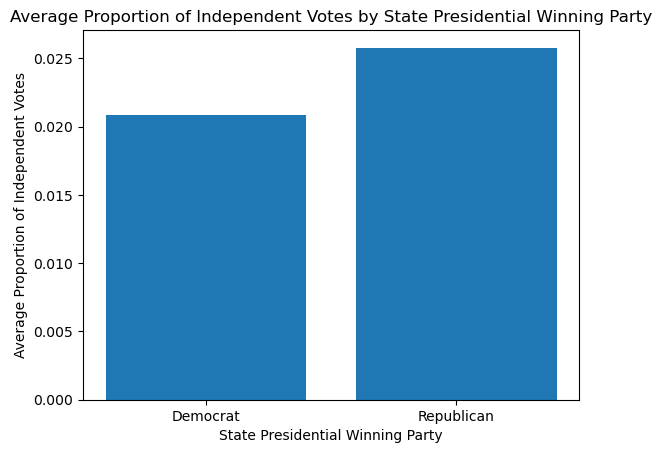

In [5]:
# Abby's code and graph

#groups pres_proportions by "Winner" which is the party the state voted for president.
#Proportion_Independent"].mean() takes the mean of the proportion of independent votes for democratic and republican states
ind_prop_party = pres_proportions.groupby(by = "Winner")["Proportion_Independent"].mean()
display(ind_prop_party)

party = ["Democrat", "Republican"]
count = [ind_prop_party.iloc[0],ind_prop_party.iloc[1]] #Grabs the proportion of indpendent votes for democrats and republicans respectively
plt.bar(x=party, height=count)
plt.xlabel("State Presidential Winning Party")
plt.ylabel("Average Proportion of Independent Votes")
plt.title("Average Proportion of Independent Votes by State Presidential Winning Party")
plt.show()

##### Abby's explanation of the findings (fill out)

#### Subquestion 2: Are states with a greater mix of Republicans and Democrats more likely to have more votes for an independent candidate?

,State,Proportion_Democrat,Proportion_Republican,Proportion_Independent,Winner,Dem-Rep,margin,margin_abs
0,Alabama,0.365707,0.620310,0.013984,REP,-0.254603,-0.254603,0.254603
1,Alaska,0.391993,0.485228,0.122779,REP,-0.093235,-0.093235,0.093235
2,Arizona,0.493647,0.490560,0.015793,DEM,0.003087,0.003087,0.003087
3,Arkansas,0.347751,0.623957,0.028292,REP,-0.276207,-0.276207,0.276207
4,California,0.634992,0.343278,0.021730,DEM,0.291714,0.291714,0.291714
5,Colorado,0.554000,0.418983,0.027017,DEM,0.135017,0.135017,0.135017
6,Connecticut,0.592387,0.392095,0.015518,DEM,0.200292,0.200292,0.200292
7,Delaware,0.587822,0.398014,0.014164,DEM,0.189808,0.189808,0.189808
8,District of Columbia,0.921497,0.053973,0.024530,DEM,0.867524,0.867524,0.867524
9,Florida,0.478615,0.512198,0.009187,REP,-0.033584,-0.033584,0.033584


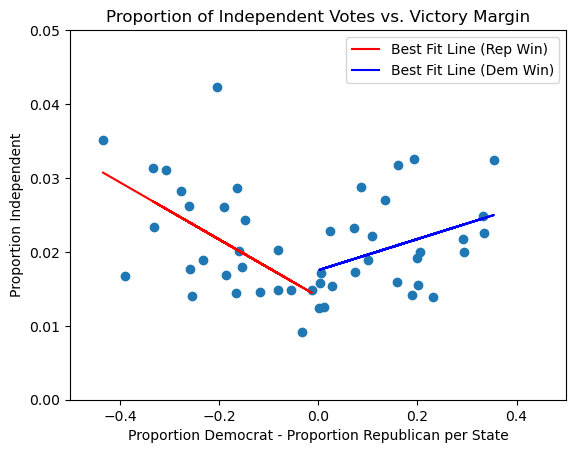

In [32]:
# Susanna's code and graph

#this creates a new column that shows the winning margin for each state by subtracting the proportion of republican votes from the proportion of democratic votes. A positive value shows that Democrats won and a negative value shows that republicans won.
pres_proportions["Dem-Rep"] = pres_proportions["Proportion_Democrat"] - pres_proportions["Proportion_Republican"]
display(pres_proportions)

#this creates new x and y values without the outliers
no_out_x = pres_proportions["Dem-Rep"].loc[(pres_proportions["Dem-Rep"] < 0.5) & (pres_proportions["Dem-Rep"] > -0.5) & (pres_proportions["Proportion_Independent"] < 0.06)]
no_out_y = pres_proportions["Proportion_Independent"].loc[(pres_proportions["Dem-Rep"] < 0.5) & (pres_proportions["Dem-Rep"] > -0.5) & (pres_proportions["Proportion_Independent"] < 0.06)]

plt.scatter(no_out_x, no_out_y)
plt.xlim(-0.5, 0.5) 
plt.ylim(0, 0.05)
plt.xlabel("Proportion Democrat - Proportion Republican per State")
plt.ylabel("Proportion Independent")
plt.title("Proportion of Independent Votes vs. Victory Margin")

#this creates the first line that shows the line of best fit for the margins where republicans won (negative margin)
first_pres = no_out_x.loc[pres_proportions["Dem-Rep"] < 0]
first_ind = no_out_y.loc[pres_proportions["Dem-Rep"] < 0]
coefficients = np.polyfit(first_pres, first_ind, 1)
slope, intercept = coefficients
best_fit_line = slope * first_pres + intercept
plt.plot(first_pres, best_fit_line, color='red', label='Best Fit Line (Rep Win)')


#this creates the second line that shows the line of best fit for the margins where democrats won (positive margin)
sec_pres = no_out_x.loc[pres_proportions["Dem-Rep"] > 0]
sec_ind = no_out_y.loc[pres_proportions["Dem-Rep"] > 0]
coefficients = np.polyfit(sec_pres, sec_ind, 1)
slope, intercept = coefficients
best_fit_line = slope * sec_pres + intercept
plt.plot(sec_pres, best_fit_line, color='blue', label='Best Fit Line (Dem Win)')

plt.legend()
plt.show()

##### Susanna's explanation of the findings
This graph shows the relationship between the margin of winning to the proportion of independent votes per state. The graph shows that as the margin of winning becomes greater, the proportion of independent votes increases. The graph also shows that there is a greater proportion of independent votes when Republicans win, compared to when Democrats win. 

#### Subquestion 3: How often does a state’s presidential party vote match the senator, house rep and governor party?

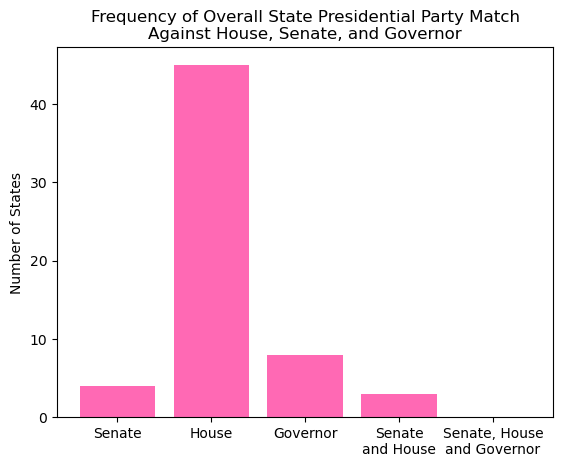

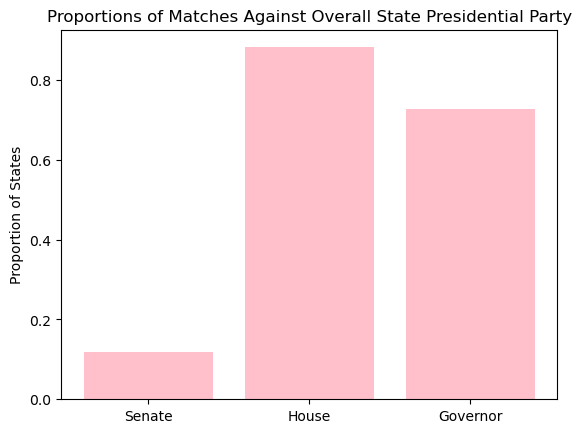

In [7]:
# Michelle's code and graph

from panel import state


labels = [
    "President vs Senate",
    "President vs House Majority",
    "President vs Governor",
    "President vs Senate & House",
    "President vs Senate, House & Governor"
    ]

raw_counts = [
    len(merged.query("Winner == Senator_Party")),
    len(merged.query("Winner == House_Majority")),
    len(merged.query("(Winner == Governor_Party)")),
    len(merged.query("(Winner == House_Majority) and (Winner==Senator_Party)")),
    len(merged.query("(Winner == House_Majority) and (Winner==Senator_Party) and (Winner==Governor_Party)"))
    ]

proportions = [
    len(merged.query("Winner == Senator_Party"))/len(sen["state"].unique()),
    len(merged.query("Winner == House_Majority"))/len(house["States"].unique()),
    len(merged.query("(Winner == Governor_Party)"))/len(gov["state"].unique()),
    len(merged.query("(Winner == House_Majority) and (Winner==Senator_Party)"))/len(pres["state"].unique()),
    len(merged.query("(Winner == House_Majority) and (Winner==Senator_Party) and (Winner==Governor_Party)"))/len(pres["state"].unique())
]

relevant_states = [
    merged.query("Winner == Senator_Party")["State"].tolist(),
    merged.query("Winner == House_Majority")["State"].tolist(),
    merged.query("(Winner == Governor_Party)")["State"].tolist(),
    merged.query("(Winner == House_Majority) and (Winner==Senator_Party)")["State"].tolist(),
    "N/A"
]
match_table = pd.DataFrame({"Comparisons": labels , "Number_of_States" : raw_counts, "Proportion" : proportions, "Relevant_States" : relevant_states})
round(match_table,2)

# Raw counts of number of matches 
categories = ["Senate", "House", "Governor", "Senate\nand House", "Senate, House\nand Governor"]
num_states = raw_counts 
#created from table above

plt.bar(x = categories, height = num_states, color = "hotpink")
plt.ylabel("Number of States")
plt.title("Frequency of Overall State Presidential Party Match\nAgainst House, Senate, and Governor")
plt.show()

#Proportions of matches among states that participated for each elected position
categories = ["Senate", "House", "Governor"]
proportions_state = [    
    len(merged.query("Winner == Senator_Party"))/len(sen["state"].unique()),
    len(merged.query("Winner == House_Majority"))/len(house["States"].unique()),
    len(merged.query("(Winner == Governor_Party)"))/len(gov["state"].unique())]

plt.bar(x = categories, height = proportions_state, color = "pink")
plt.ylabel("Proportion of States")
plt.title("Proportions of Matches Against Overall State Presidential Party")
plt.show()

##### Michelle's explanation of the findings
The first bar graph compares the raw count of states that have the same political party between their senate, house, and governor elections when compared to overall presidential elections.
The second bar graph provides the proportion of states that have the same political party as their overall presidential party, AMONG the ones that did particpate in elections for their respective groups in the x-axis. For instance, among the 34 states that elected new senators in the 2020 US Elections, ~12% had the same political group for their senator and president. 

For the most part, political parties were identical across presidential and house majority elections. A large proportion of states that did elect new governors for the 2020 cycle also had an identical political party to their presidential party. The frequency just appears lower due the limited governors elected. This information is consistent with what we'd expect in that states with a general political ideology will opt to elect leaders with identify in the same party. 
What stands out is the how many senators elected identified with political parties that were different than their state's presidential party. This could be due to other factors such as geography, economic standing, and education level of voters in the state. Future research could look into these variables and obtain a more detailed dataset. 

#### Subquestion 4: What percentage of the time do the chosen president, senator, house representative, and governor match in party for presidential swing states? 

In [8]:
# Angie's code and graph

pres_proportions["margin"] = pres_proportions["Proportion_Democrat"] - pres_proportions["Proportion_Republican"]
pres_proportions["margin_abs"] = abs(pres_proportions["margin"])
swing = pres_proportions.query("margin_abs <= 0.05")
swing

,State,Proportion_Democrat,Proportion_Republican,Proportion_Independent,Winner,Dem-Rep,margin,margin_abs
2,Arizona,0.493647,0.490560,0.015793,DEM,0.003087,0.003087,0.003087
9,Florida,0.478615,0.512198,0.009187,REP,-0.033584,-0.033584,0.033584
10,Georgia,0.494953,0.492596,0.012451,DEM,0.002357,0.002357,0.002357
22,Michigan,0.506208,0.478373,0.015419,DEM,0.027835,0.027835,0.027835
28,Nevada,0.500568,0.476662,0.022770,DEM,0.023905,0.023905,0.023905
33,North Carolina,0.485862,0.499343,0.014794,REP,-0.013481,-0.013481,0.013481
38,Pennsylvania,0.499609,0.487818,0.012573,DEM,0.011792,0.011792,0.011792
49,Wisconsin,0.494540,0.488290,0.017170,DEM,0.006250,0.006250,0.006250


##### Angie's explanation of the findings

#### Subquestion 5: What are the proportions of Democrats and Republicans in the senate and house compared to the winning margin of presidential swing states?

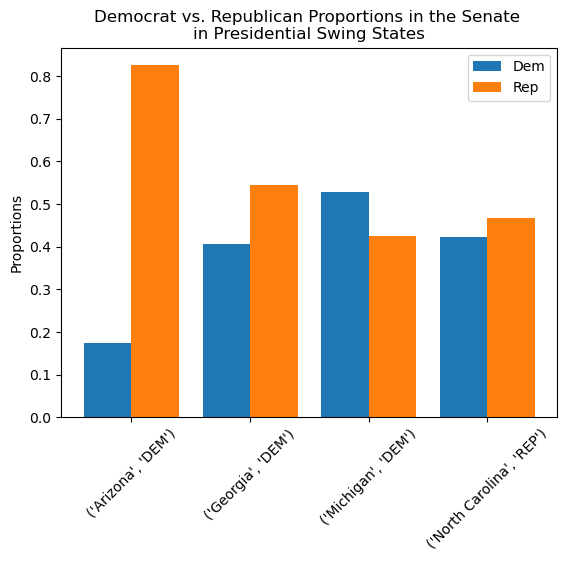

,State,Proportion_Democrat,Proportion_Republican,Proportion_Independent,Winner
2,Arizona,0.0,1.0,0.0,REP
6,Georgia,0.0,1.0,0.0,REP
15,Michigan,1.0,0.0,0.0,DEM
23,North Carolina,0.0,0.0,0.0,REP


2

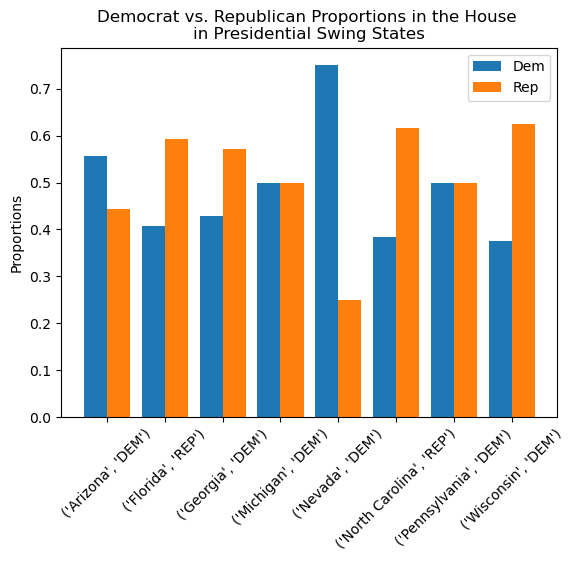

,State,Proportion_Democrat,Proportion_Republican,Proportion_Independent,Total_Reps,House_Majority
2,Arizona,1.0,0.0,0.0,9,DEM
8,Florida,0.0,1.0,0.0,27,REP
9,Georgia,0.0,1.0,0.0,14,REP
21,Michigan,0.0,0.0,0.0,14,TIE
27,Nevada,1.0,0.0,0.0,4,DEM
32,North Carolina,0.0,1.0,0.0,13,REP
37,Pennsylvania,0.0,0.0,0.0,18,TIE
48,Wisconsin,0.0,1.0,0.0,8,REP


3

In [ ]:
# Susanna's code and graph

cats = swing["State"].tolist() # created a list of states that are presidential swings

senate = sen_proportions.query("State in @cats") # took the senate proportions of states that are presidential swings
senate_list = senate["State"].tolist()

pres_swing = pres_proportions.query("State in @senate_list") # took the presidential proportions of states that are presidential swings    
presswing_list = pres_swing["Winner"].tolist()

paired = list(zip(senate_list, presswing_list))

v1, v2 = senate["Proportion_Democrat"], senate["Proportion_Republican"]
w, x = 0.4, np.arange(len(paired))

plt.bar(x - w/2, v1, w, label='Dem')
plt.bar(x + w/2, v2, w, label='Rep')

plt.xticks(x, paired, rotation=45)
plt.ylabel('Proportions')
plt.title('Democrat vs. Republican Proportions in the Senate \nin Presidential Swing States')
plt.legend()
plt.show()


house = house_proportions.query("State in @cats") # took the house proportions of states that are presidential swings
house_list = house["State"].tolist() # created a list of states that have house proportions of presidential swings

pres_swing_house = pres_proportions.query("State in @house_list") # took the presidential proportions of states that are presidential swings    
presswing_list_house = pres_swing_house["Winner"].tolist()

paired2 = list(zip(house_list, presswing_list_house))

v1, v2 = house["Proportion_Democrat"], house["Proportion_Republican"]
w, x = 0.4, np.arange(len(paired2))

plt.bar(x - w/2, v1, w, label='Dem')
plt.bar(x + w/2, v2, w, label='Rep')

plt.xticks(x, paired2, rotation=45)
plt.ylabel('Proportions')
plt.title('Democrat vs. Republican Proportions in the House \nin Presidential Swing States')
plt.xticks(rotation=45)
plt.legend()
plt.show()

##### Susanna's explanation of the findings

The first graph shows the distribution of the Senate votes by parties in the presidential swing with the x-axis label indicating which way the presidential election ended up going while the second graph shows the same distribution but with the House of Representative. There are only 4 state senate votes in the 2020 year that were also presidential swings, so the first graph only had 4 states. The data does not have a specific pattern, meaning that swing states' house and senate votes are not correlated to their swing state status or what party ended up winning the state in the presidential election. However, there is a slight trend of the house and senate going the party direction of the presidential election. 

#### Subquestion 6: Is there an association between the victory margin in the presidential election and the proportion of party votes in the Senate and House.

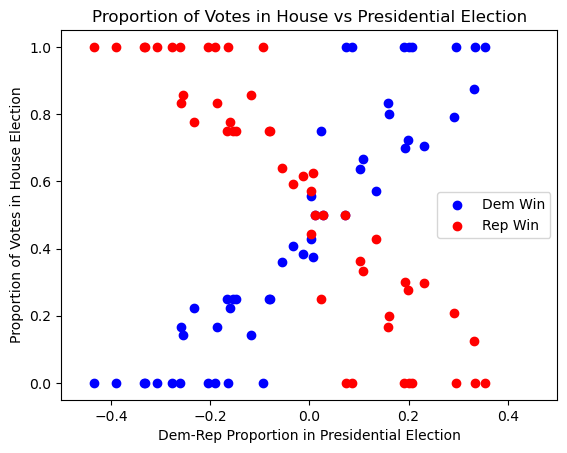

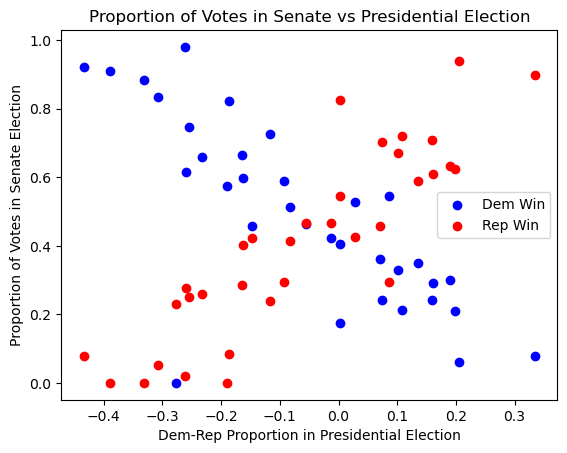

In [59]:
# Susanna's code and graph

pres_props = pres_proportions.query("State != 'District of Columbia'") #removed DC because it is not a state

plt.scatter(pres_props["Dem-Rep"], house_proportions["Proportion_Democrat"], label = "Dem Win", color = "blue")
plt.scatter(pres_props["Dem-Rep"], house_proportions["Proportion_Republican"], label = "Rep Win", color = "red")
plt.xlim(-0.5, 0.5)
plt.xlabel("Dem-Rep Proportion in Presidential Election")
plt.ylabel("Proportion of Votes in House Election")
plt.title("Proportion of Votes in House vs Presidential Election")
plt.legend()
plt.show()

senate_list = sen["state"].tolist() #created a list of states that have senate proportions
pres_props2 = pres_proportions.query("State in @senate_list") #created a list of states that are in the senate list and a swing state

plt.scatter(pres_props2["Dem-Rep"], sen_proportions["Proportion_Democrat"], label = "Dem Win", color = "blue")
plt.scatter(pres_props2["Dem-Rep"], sen_proportions["Proportion_Republican"], label = "Rep Win", color = "red")
plt.xlabel("Dem-Rep Proportion in Presidential Election")
plt.ylabel("Proportion of Votes in Senate Election")
plt.title("Proportion of Votes in Senate vs Presidential Election")
plt.legend()
plt.show()

##### Susanna's explanation of the findings

The first graph shows the association between the winning margin of the presidential election and the republican and democratic proportion distribution in the House of representative votes. The results show that when one party win the presidential election in a state, they usually win the house in that state too. This seems reasonable since if a state usually votes one party, they will usually vote the same party between the presidential and house elections.

The second graph shows the association between the winning margin of the presidential election and the republican and democratic proportion distribution in the Senate votes. These results are interesting since when one party win the presidential election in a state, the opposite party wins the senate votes in that state. A variety of factors can explain this including incumbency, votor turnout, local issues, and candidates, but further research is needed to find the exact reasoning.

## Discussion:
##### summarize findings and main things learned 1-2 paragraphs (fill out)